In [7]:
# Set up our code and import new datasets, tell the user where 
# the data set has been imported to.

!pip install kagglehub

import kagglehub
import pandas
import os

path = kagglehub.dataset_download("martinsn/high-frequency-crypto-limit-order-book-data")
print("Path to dataset files:", path)

print(os.path.basename(path))

df = pandas.read_csv(os.path.join(path, "BTC_1min.csv"))
df.head()

Path to dataset files: /Users/harshelgopiinaath/.cache/kagglehub/datasets/martinsn/high-frequency-crypto-limit-order-book-data/versions/1
1


,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_5,asks_market_notional_6,asks_market_notional_7,asks_market_notional_8,asks_market_notional_9,asks_market_notional_10,asks_market_notional_11,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14
0,0,2021-04-07 11:33:41.122161+00:00,55896.285,0.01,4.448599e+06,3.899402e+06,-8.945138e-08,-0.000065,-0.000073,-0.000154,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1176.72998,0.0
1,1,2021-04-07 11:34:41.122161+00:00,55948.685,1.43,1.243244e+06,3.606502e+06,-1.277957e-05,-0.000013,-0.000242,-0.000242,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2,2,2021-04-07 11:35:41.122161+00:00,56013.785,0.01,3.069094e+06,1.575759e+06,-8.926374e-08,-0.000009,-0.000070,-0.000088,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3,3,2021-04-07 11:36:41.122161+00:00,55903.575,7.17,1.220819e+06,1.321487e+06,-6.412827e-05,-0.000182,-0.000188,-0.000225,...,0.0,312.040009,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
4,4,2021-04-07 11:37:41.122161+00:00,55899.995,0.01,2.011287e+06,3.083005e+06,-8.944544e-08,-0.000129,-0.000130,-0.000143,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


In [8]:
# Make a new dataframe with our imbalance and other features at every 
# snapshot which we can train our tree model on

# Level 0 imbalance
df["imbalance"] = (
    (df["bids_notional_0"] - df["asks_notional_0"])
    / (df["bids_notional_0"] + df["asks_notional_0"])
)

# Multi-level imbalance
bid_cols = [f"bids_notional_{i}" for i in range(15)]
ask_cols = [f"asks_notional_{i}" for i in range(15)]

df["total_bid_notional"] = df[bid_cols].sum(axis=1)
df["total_ask_notional"] = df[ask_cols].sum(axis=1)

df["multi_level_imbalance"] = (
    (df["total_bid_notional"] - df["total_ask_notional"])
    / (df["total_bid_notional"] + df["total_ask_notional"])
)

# Rolling imbalance (smoothed)
window = 20
df["rolling_imbalance"] = df["imbalance"].rolling(window).mean()

# Momentum
df["momentum"] = df["midpoint"].diff(window)

# Trade flow imbalance (executed buys/sells, not resting orders)
df["trade_imbalance"] = (df["buys"] - df["sells"]) / (df["buys"] + df["sells"])

df.head()

/var/folders/pk/4w4qkjsj3yl47jbnbpwx88vh0000gn/T/ipykernel_23156/4008177786.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["imbalance"] = (
/var/folders/pk/4w4qkjsj3yl47jbnbpwx88vh0000gn/T/ipykernel_23156/4008177786.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["total_bid_notional"] = df[bid_cols].sum(axis=1)
/var/folders/pk/4w4qkjsj3yl47jbnbpwx88vh0000gn/T/ipykernel_23156/4008177786.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

,Unnamed: 0,system_time,midpoint,spread,buys,sells,bids_distance_0,bids_distance_1,bids_distance_2,bids_distance_3,...,asks_market_notional_12,asks_market_notional_13,asks_market_notional_14,imbalance,total_bid_notional,total_ask_notional,multi_level_imbalance,rolling_imbalance,momentum,trade_imbalance
0,0,2021-04-07 11:33:41.122161+00:00,55896.285,0.01,4.448599e+06,3.899402e+06,-8.945138e-08,-0.000065,-0.000073,-0.000154,...,0.0,1176.72998,0.0,-0.039332,92958.590069,3.766060e+05,-0.604065,NaN,NaN,0.065788
1,1,2021-04-07 11:34:41.122161+00:00,55948.685,1.43,1.243244e+06,3.606502e+06,-1.277957e-05,-0.000013,-0.000242,-0.000242,...,0.0,0.00000,0.0,-0.427911,229288.928085,2.585486e+06,-0.837082,NaN,NaN,-0.487295
2,2,2021-04-07 11:35:41.122161+00:00,56013.785,0.01,3.069094e+06,1.575759e+06,-8.926374e-08,-0.000009,-0.000070,-0.000088,...,0.0,0.00000,0.0,0.999936,160681.961151,3.428114e+05,-0.361732,NaN,NaN,0.321503
3,3,2021-04-07 11:36:41.122161+00:00,55903.575,7.17,1.220819e+06,1.321487e+06,-6.412827e-05,-0.000182,-0.000188,-0.000225,...,0.0,0.00000,0.0,-0.999056,83091.429621,2.377862e+06,-0.932472,NaN,NaN,-0.039597
4,4,2021-04-07 11:37:41.122161+00:00,55899.995,0.01,2.011287e+06,3.083005e+06,-8.944544e-08,-0.000129,-0.000130,-0.000143,...,0.0,0.00000,0.0,-0.966004,147636.929535,1.193890e+06,-0.779897,NaN,NaN,-0.210376


In [9]:
# Define our time horizon and target condition

horizon = 10 # can change
df["future_price"] = df["midpoint"].shift(-horizon)
df["target"] = (df["future_price"] > df["midpoint"]).astype(int) # classify price down or up

/var/folders/pk/4w4qkjsj3yl47jbnbpwx88vh0000gn/T/ipykernel_23156/3921121007.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["future_price"] = df["midpoint"].shift(-horizon)
/var/folders/pk/4w4qkjsj3yl47jbnbpwx88vh0000gn/T/ipykernel_23156/3921121007.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"] = (df["future_price"] > df["midpoint"]).astype(int) # classify price down or up


In [10]:
# Split our data into past data to train on, and future data to test on

features = ["imbalance", "multi_level_imbalance", "rolling_imbalance", "momentum", "trade_imbalance", "spread"]

df = df[df["future_price"].notna() & df[features].notna().all(axis=1)].reset_index(drop=True)

split_point = int(len(df) * 0.8)
train = df.iloc[:split_point - horizon]
test = df.iloc[split_point:]

print(f"train {len(train)}  test {len(test)}")

train 13656  test 3417


In [11]:
# Train and test our machine learning model on past data 

import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

X_train, y_train = train[features], train["target"]
X_test, y_test = test[features], test["target"]

model = xgb.XGBClassifier(n_estimators = 100, max_depth = 4, learning_rate = 0.1)
model.fit(X_train, y_train)

preds = model.predict(X_test)

0.5381913959613697
0.5229645093945721
0.6014405762304922
0.559463986599665
[[ 837  914]
 [ 664 1002]]


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

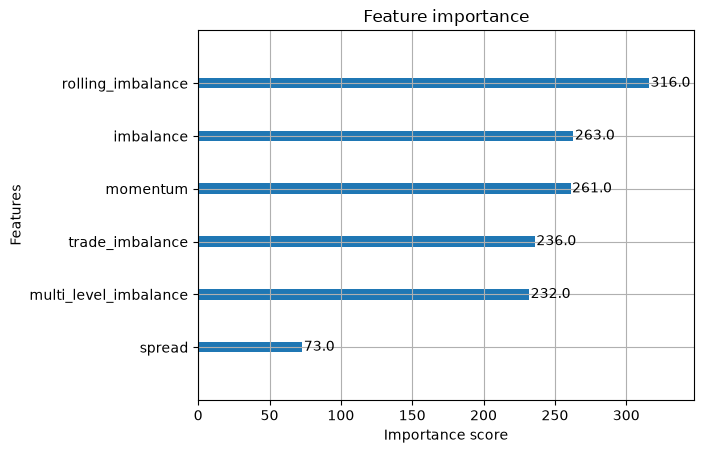

In [12]:
# Print our scores to evaluate effectiveness of the strategy

print(accuracy_score(y_test, preds))
print(precision_score(y_test, preds))
print(recall_score(y_test, preds))
print(f1_score(y_test, preds))
print(confusion_matrix(y_test, preds))

xgb.plot_importance(model)